In [1]:
!pip install opencv-python matplotlib numpy

In [2]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2026-01-27 at 9.52.53 PM.jpeg to WhatsApp Image 2026-01-27 at 9.52.53 PM.jpeg


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [4]:
# Convert to grayscale
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# ----------------------------
# STEP 1: Noise reduction (mild but effective)
# ----------------------------
denoised = cv2.fastNlMeansDenoising(
    gray,
    None,
    h=10,
    templateWindowSize=7,
    searchWindowSize=21
)

# ----------------------------
# STEP 2: Contrast enhancement (light)
# ----------------------------
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast_enhanced = clahe.apply(denoised)

# ----------------------------
# STEP 3: Strong edge enhancement (Unsharp Mask)
# ----------------------------
blur = cv2.GaussianBlur(contrast_enhanced, (5,5), 0)
restored = cv2.addWeighted(
    contrast_enhanced, 1.6,
    blur, -0.6,
    0
)

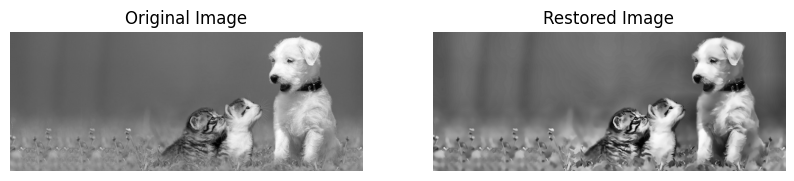

In [5]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Restored Image")
plt.imshow(restored, cmap='gray')
plt.axis('off')

plt.show()